# Valuación de Puts Americanas — LSM Clásico vs LSM-SVR
## Tesis: Aprendizaje Estadístico en Opciones Americanas — UNAM

Pipeline completo para **N emisoras configurables**. Produce todas las gráficas
y tablas requeridas en el documento LaTeX de la tesis.

### Estructura
| Sección | Contenido |
|---|---|
| 1–2 | Dependencias e importaciones |
| 3 | Configuración global (emisoras, rutas, parámetros) |
| 4 | Descarga de datos y estadísticos descriptivos |
| 5 | Gráficas exploratorias (precios, velas, rendimientos) |
| 6 | Distribución de rendimientos (histograma, QQ-plot, densidad) |
| 7 | Distribuciones mundo real vs mundo riesgo-neutro |
| 8 | Simulación GBM y gráficas de trayectorias |
| 9 | LSM-Clásico (OLS polinomial) |
| 10 | LSM-SVR (contribución principal) |
| 11 | Black-Scholes benchmark |
| 12 | Análisis comparativo: 11 ratios de moneyness |
| 13 | Gráficas comparativas (primas, tiempos, variabilidad) |
| 14 | Análisis de sensibilidad a C (SVR) |
| 15 | Exportar tablas LaTeX y figuras |


## 1. Dependencias

In [1]:
import subprocess, sys
for p in ["yfinance","pandas","numpy","matplotlib","scipy","seaborn","scikit-learn","mplfinance"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])
print("✅ Dependencias listas")



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


✅ Dependencias listas



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


## 2. Importaciones

In [2]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import mplfinance as mpf
import yfinance as yf

from datetime import date
from scipy import stats
from scipy.stats import norm, jarque_bera
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

# Estilo global de gráficas
plt.rcParams.update({
    'font.family':      'serif',
    'axes.titlesize':   11,
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
    'legend.fontsize':  8,
    'figure.dpi':       120,
})

print("✅ Importaciones listas")


✅ Importaciones listas


## 3. Configuración Global

**Edita esta celda** para cambiar emisoras, rutas y parámetros de simulación.
Todo el notebook se adapta automáticamente a cualquier número de emisoras.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN — EDITAR AQUÍ
# ═══════════════════════════════════════════════════════════════════════════════

# Emisoras: dict {ticker: 'Nombre corto para gráficas'}
# Agrega o quita las que quieras — el resto del notebook se adapta solo
EMISORAS = {
    'WALMEX.MX':    'Walmart de México',
    'AC.MX':        'Arca Continental',
    'NVDA':         'NVIDIA',
    'AAPL':         'Apple Inc.',
    'CEMEXCPO.MX':  'Cemex',
}
# Rutas
RUTA_DATOS    = '/Users/leohdezj/Personal/GitHub/Tesis/data'
RUTA_IMAGENES = '/Users/leohdezj/Personal/GitHub/Tesis/Imagenes'

# Periodo histórico para datos
FECHA_INICIO = '2015-01-01'
FECHA_FIN    = date.today().strftime('%Y-%m-%d')

# Parámetros de valuación
T         = 1.0          # horizonte en años
dt        = 1 / 252      # paso diario
NUM_PATHS = 100_000      # trayectorias (100k para tesis, baja a 1k para pruebas)
SEED      = 42           # semilla global para reproducibilidad

# Ratios de moneyness S0/K
RATIOS_MONEYNESS = [0.75, 0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20, 1.25]

# Hiperparámetros SVR (justificados en tesis: kernel RBF, C fijo con análisis de sensibilidad)
SVR_C     = 10.0
SVR_GAMMA = 'scale'      # gamma = 1/(n_features * Var(X)) — más estable que valor fijo

# Tasa libre de riesgo — se obtiene de ^TNX; puedes fijarla manualmente aquí
# TASA_RF = 0.045   # descomenta y fija si yfinance falla

# ═══════════════════════════════════════════════════════════════════════════════
os.makedirs(RUTA_DATOS,    exist_ok=True)
os.makedirs(RUTA_IMAGENES, exist_ok=True)

N = len(EMISORAS)
TICKERS = list(EMISORAS.keys())
NOMBRES = list(EMISORAS.values())

print(f"Emisoras configuradas: {N}")
for t, n in EMISORAS.items():
    print(f"  {t:<18} {n}")
print(f"\nRuta datos:    {RUTA_DATOS}")
print(f"Ruta imágenes: {RUTA_IMAGENES}")
print(f"Trayectorias:  {NUM_PATHS:,}")
print(f"Ratios:        {RATIOS_MONEYNESS}")


Emisoras configuradas: 5
  WALMEX.MX          Walmart de México
  AC.MX              Arca Continental
  NVDA               NVIDIA
  AAPL               Apple Inc.
  CEMEXCPO.MX        Cemex

Ruta datos:    /Users/leohdezj/Personal/GitHub/Tesis/data
Ruta imágenes: /Users/leohdezj/Personal/GitHub/Tesis/Imagenes
Trayectorias:  100,000
Ratios:        [0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25]


## 4. Descarga de Datos y Estadísticos Descriptivos

In [4]:
# ── 1. Definir funciones primero ──────────────────────────────────
def obtener_tasa_rf() -> float:
    """^TNX con múltiples fallbacks."""
    if 'TASA_RF' in dir():
        print(f"Tasa fija configurada: {TASA_RF:.4f}")
        return TASA_RF
    ticker = yf.Ticker('^TNX')
    for period in ('5d', '1mo', '3mo'):
        try:
            h = ticker.history(period=period)
            if not h.empty:
                r = float(h['Close'].iloc[-1] / 100)
                print(f"✅ ^TNX ({period}): {r:.4f} ({r*100:.2f}%)")
                return r
        except Exception:
            pass
    try:
        r = float(ticker.fast_info['lastPrice'] / 100)
        print(f"✅ ^TNX (fast_info): {r:.4f}")
        return r
    except Exception:
        pass
    print("⚠️  Usando tasa por defecto 4.5%")
    return 0.045


# ── 2. Inicializar contenedores y descargar ──────────────────────────
print("Descargando datos históricos...")
DATOS    = {}   # {ticker: DataFrame con Close, Volume, Open, High, Low}
LOG_RETS = {}   # {ticker: Series de rendimientos log-diarios}
PARAMS   = {}   # {ticker: dict con S0, sigma, mu, r}

r_global = obtener_tasa_rf()

for ticker, nombre in EMISORAS.items():
    print(f"  {ticker}...", end=' ')
    df = yf.Ticker(ticker).history(start=FECHA_INICIO, end=FECHA_FIN, auto_adjust=True)

    if df.empty:
        print(f"❌ Sin datos para {ticker} (revisa símbolo/fechas)")
        continue

    df.index = pd.to_datetime(df.index).tz_localize(None)
    df = df[['Open','High','Low','Close','Volume']].dropna()

    if df.empty:
        print(f"❌ {ticker}: datos vacíos tras dropna (posibles NaNs en todo el rango)")
        continue

    log_r = np.log(df['Close'] / df['Close'].shift(1)).dropna()
    S0    = float(df['Close'].iloc[-1])
    sigma = float(log_r.std() * np.sqrt(252))
    mu    = float(log_r.mean() * 252)

    DATOS[ticker]    = df
    LOG_RETS[ticker] = log_r
    PARAMS[ticker]   = {'S0': S0, 'sigma': sigma, 'mu': mu, 'r': r_global,
                         'nombre': nombre}
    print(f"✅  {len(df)} obs | S0={S0:.2f} | σ={sigma:.4f} | μ={mu:.4f}")

print("\n✅ Datos descargados")

Descargando datos históricos...
✅ ^TNX (5d): 0.0478 (4.78%)
  WALMEX.MX... ✅  2936 obs | S0=47.18 | σ=0.2513 | μ=0.0698
  AC.MX... ✅  2936 obs | S0=192.96 | σ=0.2185 | μ=0.0961
  NVDA... ✅  2936 obs | S0=230.36 | σ=0.4787 | μ=0.5296
  AAPL... ✅  2936 obs | S0=319.97 | σ=0.2873 | μ=0.2218
  CEMEXCPO.MX... ✅  2936 obs | S0=18.64 | σ=0.3672 | μ=0.0342

✅ Datos descargados


In [5]:
# ── Estadísticos descriptivos ─────────────────────────────────────────────────
def estadisticos(log_r: pd.Series) -> dict:
    """Calcula los estadísticos requeridos en la tabla LaTeX de la tesis."""
    jb_stat, jb_p = jarque_bera(log_r)
    return {
        'Media':            log_r.mean(),
        'Mediana':          log_r.median(),
        'Varianza':         log_r.var(),
        'Desv. Estándar':   log_r.std(),
        'Mínimo':           log_r.min(),
        'Máximo':           log_r.max(),
        'Q1':               log_r.quantile(0.25),
        'Q3':               log_r.quantile(0.75),
        'Asimetría':        log_r.skew(),
        'Curtosis':         log_r.kurt(),   # exceso de curtosis
        'JB estadístico':   jb_stat,
        'JB p-valor':       jb_p,
    }

desc = {t: estadisticos(LOG_RETS[t]) for t in TICKERS}
df_desc = pd.DataFrame(desc).round(6)
df_desc.index.name = 'Estadístico'
print("=== Estadísticos descriptivos de rendimientos log-diarios ===")
print(df_desc.to_string())


=== Estadísticos descriptivos de rendimientos log-diarios ===
                 WALMEX.MX       AC.MX         NVDA         AAPL  CEMEXCPO.MX
Estadístico                                                                  
Media             0.000277    0.000381     0.002102     0.000880     0.000136
Mediana           0.000260    0.000158     0.002556     0.001000     0.000000
Varianza          0.000251    0.000189     0.000909     0.000328     0.000535
Desv. Estándar    0.015833    0.013766     0.030154     0.018098     0.023131
Mínimo           -0.086894   -0.069152    -0.207712    -0.137708    -0.095795
Máximo            0.083909    0.068407     0.260876     0.142618     0.127464
Q1               -0.009038   -0.007645    -0.012746    -0.007353    -0.012658
Q3                0.009457    0.008024     0.017499     0.009958     0.012335
Asimetría        -0.019572    0.201044     0.138819    -0.119310     0.309543
Curtosis          2.091507    1.900875     6.844952     6.212382     2.517731
JB

## 5. Gráficas Exploratorias

Una figura por emisora: precio histórico, velas y rendimientos.
Se guardan en `RUTA_IMAGENES`.


── Walmart de México ──


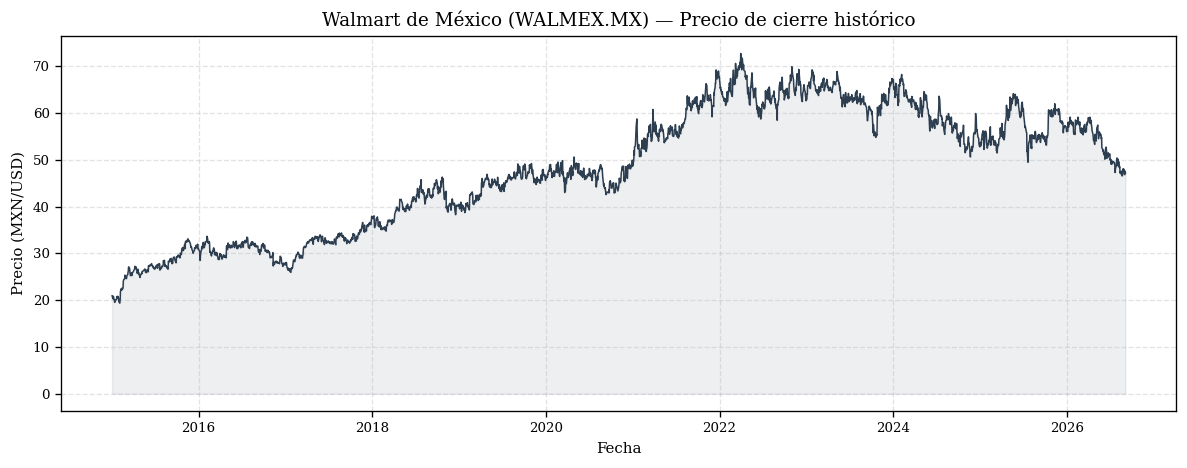

  Velas guardadas: /Users/leohdezj/Personal/GitHub/Tesis/Imagenes/WALMEX_MX_velas.png


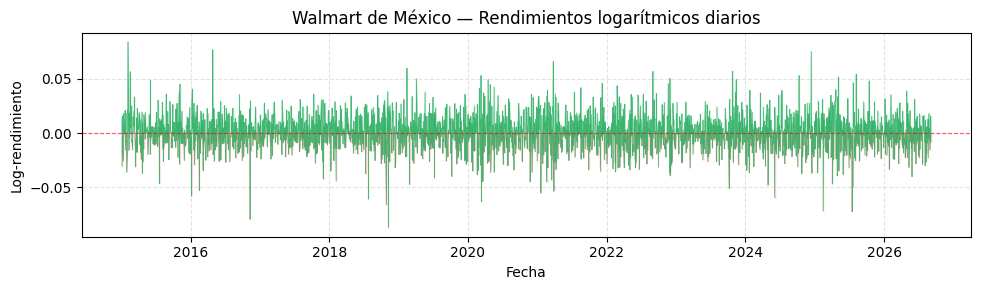

── Arca Continental ──


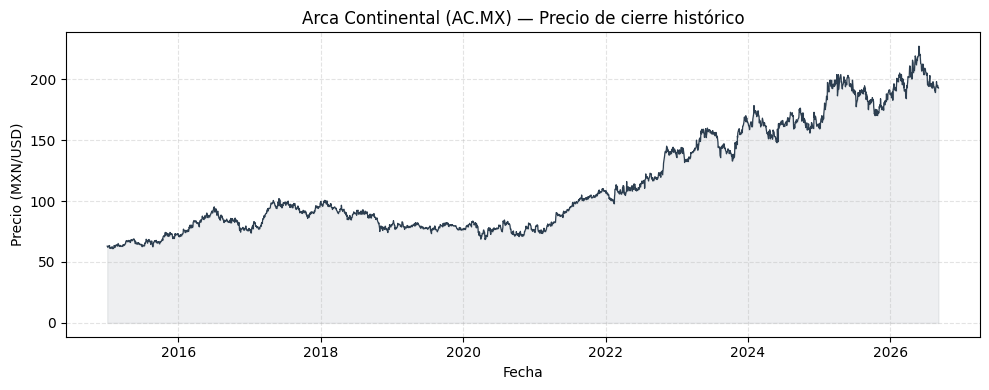

  Velas guardadas: /Users/leohdezj/Personal/GitHub/Tesis/Imagenes/AC_MX_velas.png


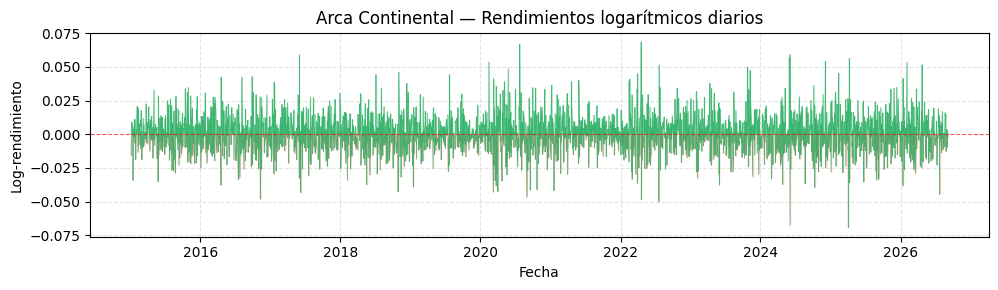

── NVIDIA ──


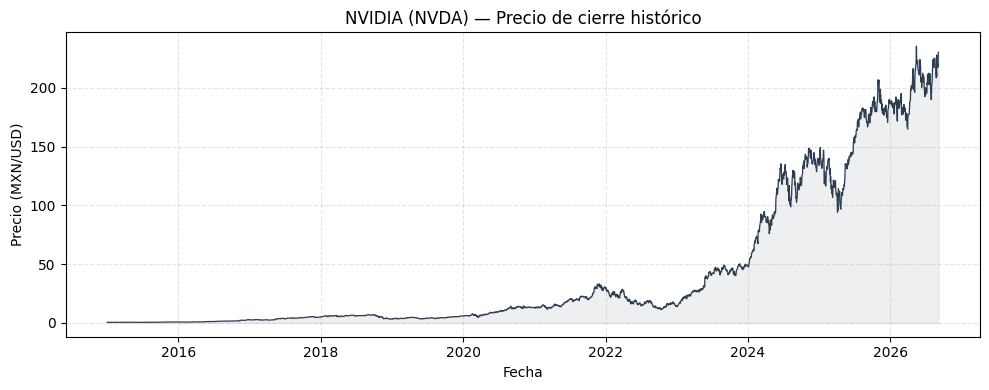

  Velas guardadas: /Users/leohdezj/Personal/GitHub/Tesis/Imagenes/NVDA_velas.png


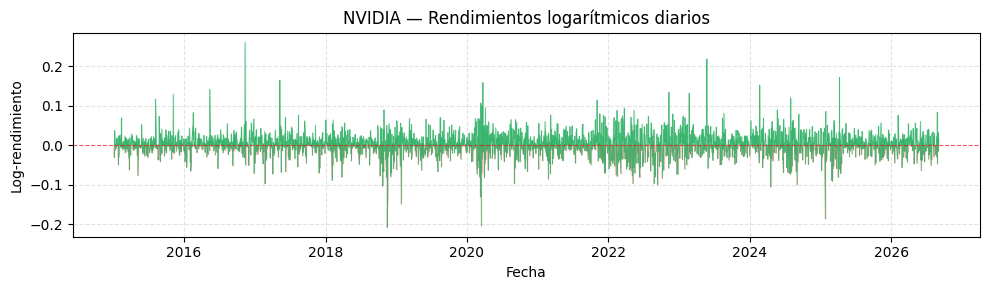

── Apple Inc. ──


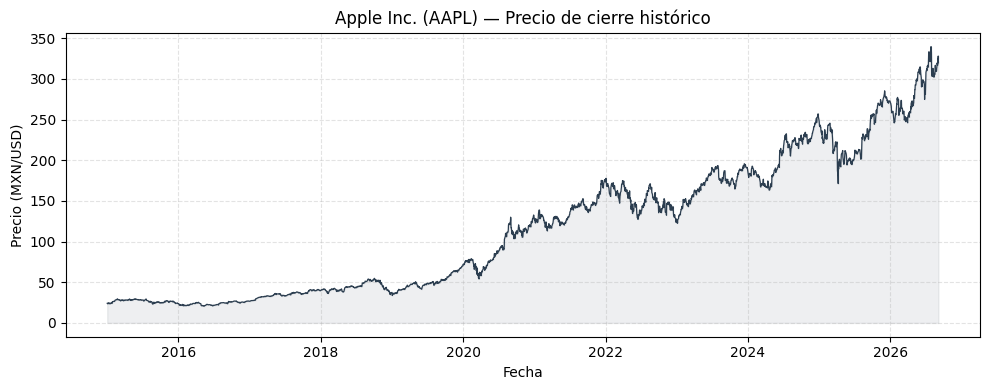

  Velas guardadas: /Users/leohdezj/Personal/GitHub/Tesis/Imagenes/AAPL_velas.png


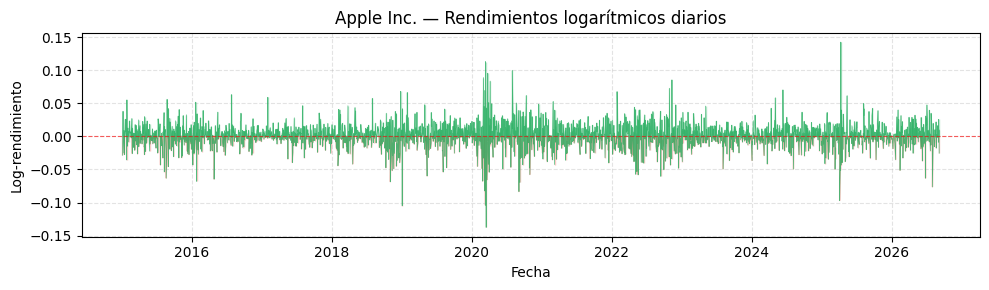

── Cemex ──


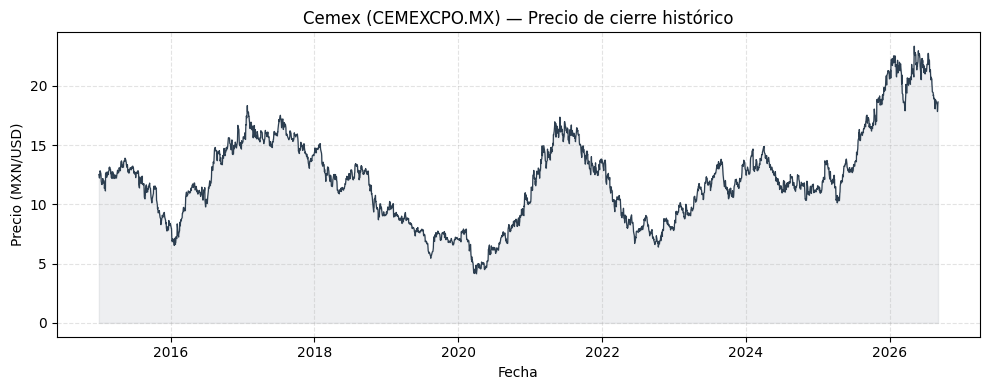

  Velas guardadas: /Users/leohdezj/Personal/GitHub/Tesis/Imagenes/CEMEXCPO_MX_velas.png


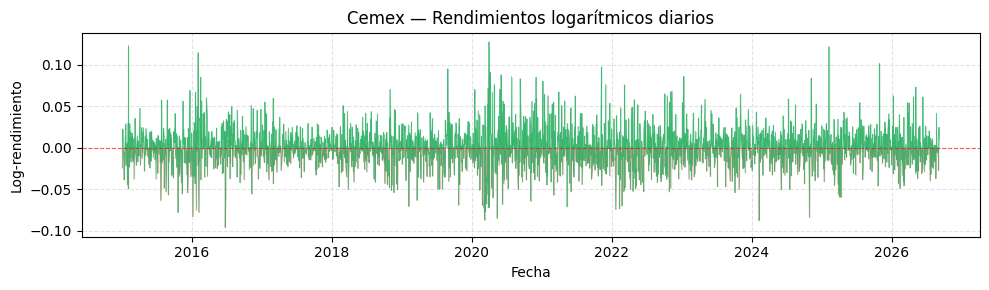

In [6]:
def graficar_exploratorio(ticker: str, nombre: str,
                           df: pd.DataFrame, log_r: pd.Series) -> None:
    """
    3 gráficas para la sección de datos de la tesis:
      1. Precio histórico (cierre)
      2. Diagrama de velas (últimos 120 días hábiles)
      3. Rendimientos log-diarios
    Guardadas individualmente en RUTA_IMAGENES.
    """
    slug = ticker.replace('.', '_').replace('-', '_')

    # ── 1. Precio histórico ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df.index, df['Close'], linewidth=0.9, color='#2c3e50')
    ax.fill_between(df.index, df['Close'], alpha=0.08, color='#2c3e50')
    ax.set_title(f'{nombre} ({ticker}) — Precio de cierre histórico')
    ax.set_xlabel('Fecha'); ax.set_ylabel('Precio (MXN/USD)')
    ax.grid(True, linestyle='--', alpha=0.35)
    plt.tight_layout()
    fig.savefig(os.path.join(RUTA_IMAGENES, f'{slug}_precio_historico.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── 2. Velas (últimos 120 días) ──────────────────────────────────────
    df_velas = df.tail(120).copy()
    mc = mpf.make_marketcolors(up='#27ae60', down='#e74c3c',
                                wick={'up':'#27ae60','down':'#e74c3c'},
                                volume='#3498db')
    s = mpf.make_mpf_style(
    marketcolors=mc,
    gridstyle='--',
    facecolor='white',
    rc={'axes.grid.axis': 'both', 'grid.alpha': 0.3}
)
    save_path = os.path.join(RUTA_IMAGENES, f'{slug}_velas.png')
    mpf.plot(df_velas, type='candle', style=s, volume=True,
             title=f'{nombre} — Últimos 120 días hábiles',
             ylabel='Precio', ylabel_lower='Volumen',
             figsize=(10, 5), savefig=save_path)
    print(f"  Velas guardadas: {save_path}")

    # ── 3. Rendimientos ──────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(log_r.index, log_r.values, linewidth=0.5, color='#27ae60', alpha=0.8)
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.fill_between(log_r.index, log_r.values, 0,
                    where=log_r.values >= 0, alpha=0.3, color='#27ae60')
    ax.fill_between(log_r.index, log_r.values, 0,
                    where=log_r.values < 0,  alpha=0.3, color='#e74c3c')
    ax.set_title(f'{nombre} — Rendimientos logarítmicos diarios')
    ax.set_xlabel('Fecha'); ax.set_ylabel('Log-rendimiento')
    ax.grid(True, linestyle='--', alpha=0.35)
    plt.tight_layout()
    fig.savefig(os.path.join(RUTA_IMAGENES, f'{slug}_rendimientos.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


for ticker in TICKERS:
    print(f"── {EMISORAS[ticker]} ──")
    graficar_exploratorio(ticker, EMISORAS[ticker], DATOS[ticker], LOG_RETS[ticker])


## 6. Distribución de Rendimientos

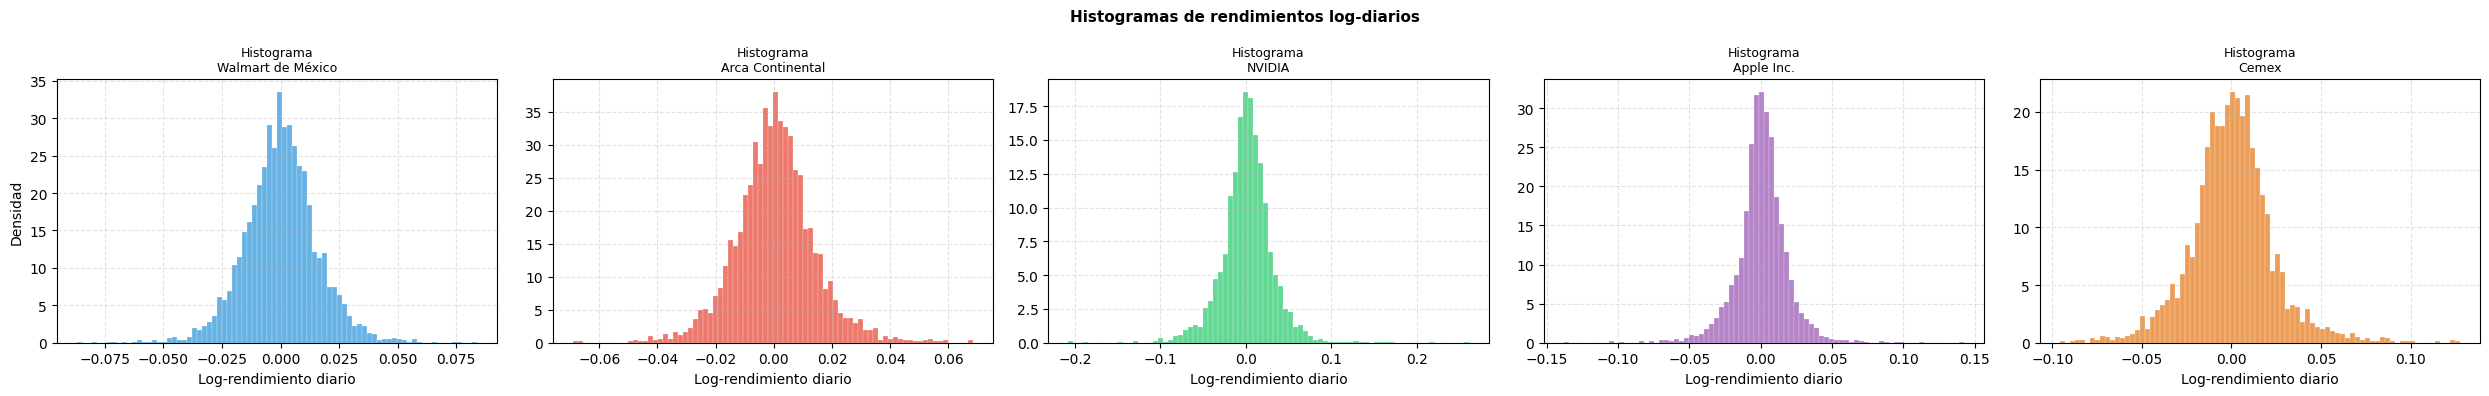

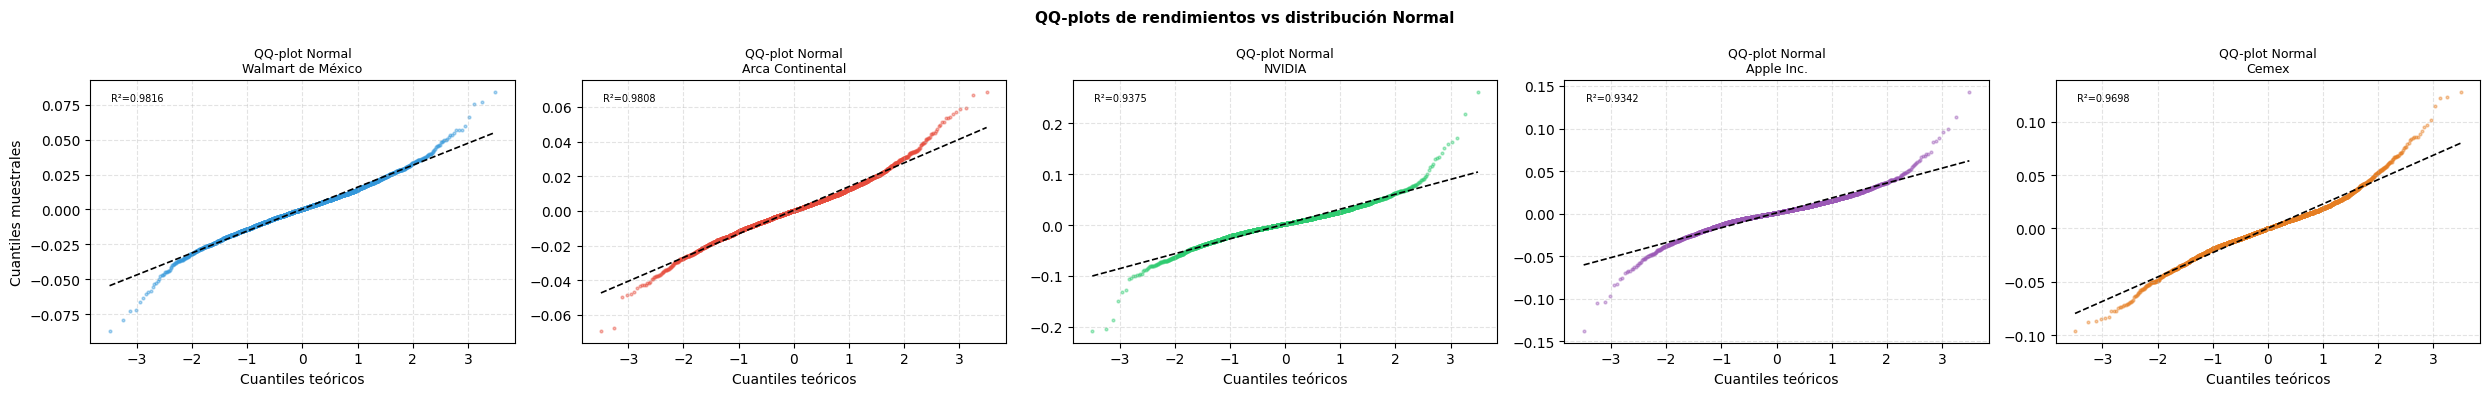

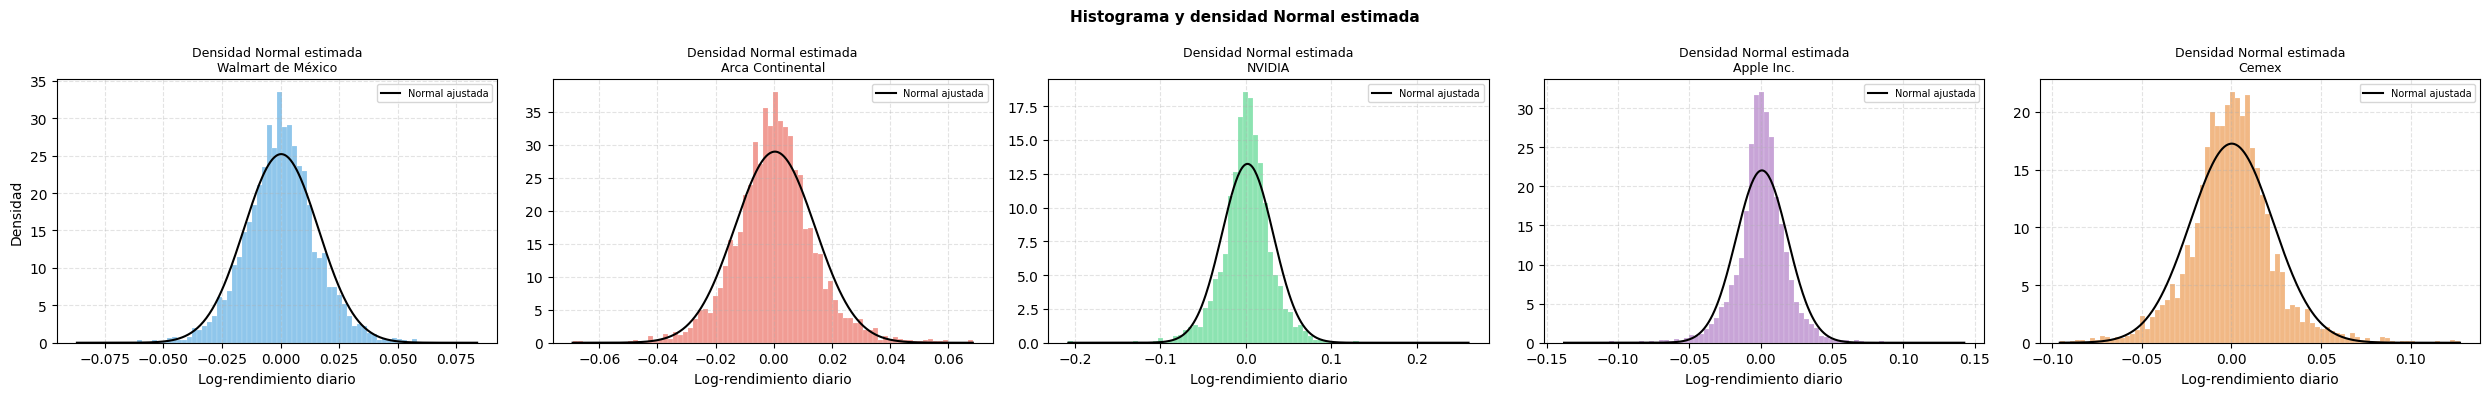

In [7]:
def graficar_distribucion_rendimientos(tickers, log_rets, nombres, ruta_img) -> None:
    """
    3 figuras comparativas (todas las emisoras en subplots horizontales):
      A. Histogramas
      B. QQ-plots vs normal
      C. Histograma + densidad normal superpuesta
    """
    n = len(tickers)
    colores = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#e67e22','#1abc9c']

    # ── A. Histogramas ───────────────────────────────────────────────────
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=False)
    if n == 1: axes = [axes]
    for ax, t, col in zip(axes, tickers, colores):
        lr = log_rets[t]
        ax.hist(lr, bins=80, density=True, color=col, alpha=0.75, edgecolor='white', lw=0.2)
        ax.set_title(f'Histograma\n{nombres[t]}', fontsize=9)
        ax.set_xlabel('Log-rendimiento diario')
        ax.set_ylabel('Densidad' if ax == axes[0] else '')
        ax.grid(True, linestyle='--', alpha=0.35)
    plt.suptitle('Histogramas de rendimientos log-diarios', fontsize=11, fontweight='bold')
    plt.tight_layout()
    fig.savefig(os.path.join(ruta_img, 'comparativa_histogramas.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # ── B. QQ-plots ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]
    for ax, t, col in zip(axes, tickers, colores):
        lr = log_rets[t]
        (osm, osr), (slope, intercept, r) = stats.probplot(lr, dist='norm')
        ax.scatter(osm, osr, s=4, alpha=0.4, color=col)
        x_line = np.array([osm[0], osm[-1]])
        ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.2)
        ax.set_title(f'QQ-plot Normal\n{nombres[t]}', fontsize=9)
        ax.set_xlabel('Cuantiles teóricos'); ax.set_ylabel('Cuantiles muestrales' if ax == axes[0] else '')
        ax.grid(True, linestyle='--', alpha=0.35)
        ax.text(0.05, 0.92, f'R²={r**2:.4f}', transform=ax.transAxes, fontsize=7)
    plt.suptitle('QQ-plots de rendimientos vs distribución Normal', fontsize=11, fontweight='bold')
    plt.tight_layout()
    fig.savefig(os.path.join(ruta_img, 'comparativa_qqplots.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # ── C. Histograma + densidad normal ──────────────────────────────────
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]
    for ax, t, col in zip(axes, tickers, colores):
        lr = log_rets[t]
        ax.hist(lr, bins=80, density=True, color=col, alpha=0.55, edgecolor='white', lw=0.2)
        x_rng = np.linspace(lr.min(), lr.max(), 400)
        ax.plot(x_rng, norm.pdf(x_rng, lr.mean(), lr.std()),
                'k-', linewidth=1.5, label='Normal ajustada')
        ax.set_title(f'Densidad Normal estimada\n{nombres[t]}', fontsize=9)
        ax.set_xlabel('Log-rendimiento diario')
        ax.set_ylabel('Densidad' if ax == axes[0] else '')
        ax.legend(fontsize=7); ax.grid(True, linestyle='--', alpha=0.35)
    plt.suptitle('Histograma y densidad Normal estimada', fontsize=11, fontweight='bold')
    plt.tight_layout()
    fig.savefig(os.path.join(ruta_img, 'comparativa_densidad_normal.png'), dpi=150, bbox_inches='tight')
    plt.show()


# Dict invertido para acceso rápido ticker→nombre
NOM = {t: EMISORAS[t] for t in TICKERS}
graficar_distribucion_rendimientos(TICKERS, LOG_RETS, NOM, RUTA_IMAGENES)


## 7. Distribuciones: Mundo Real vs Mundo Riesgo-Neutro

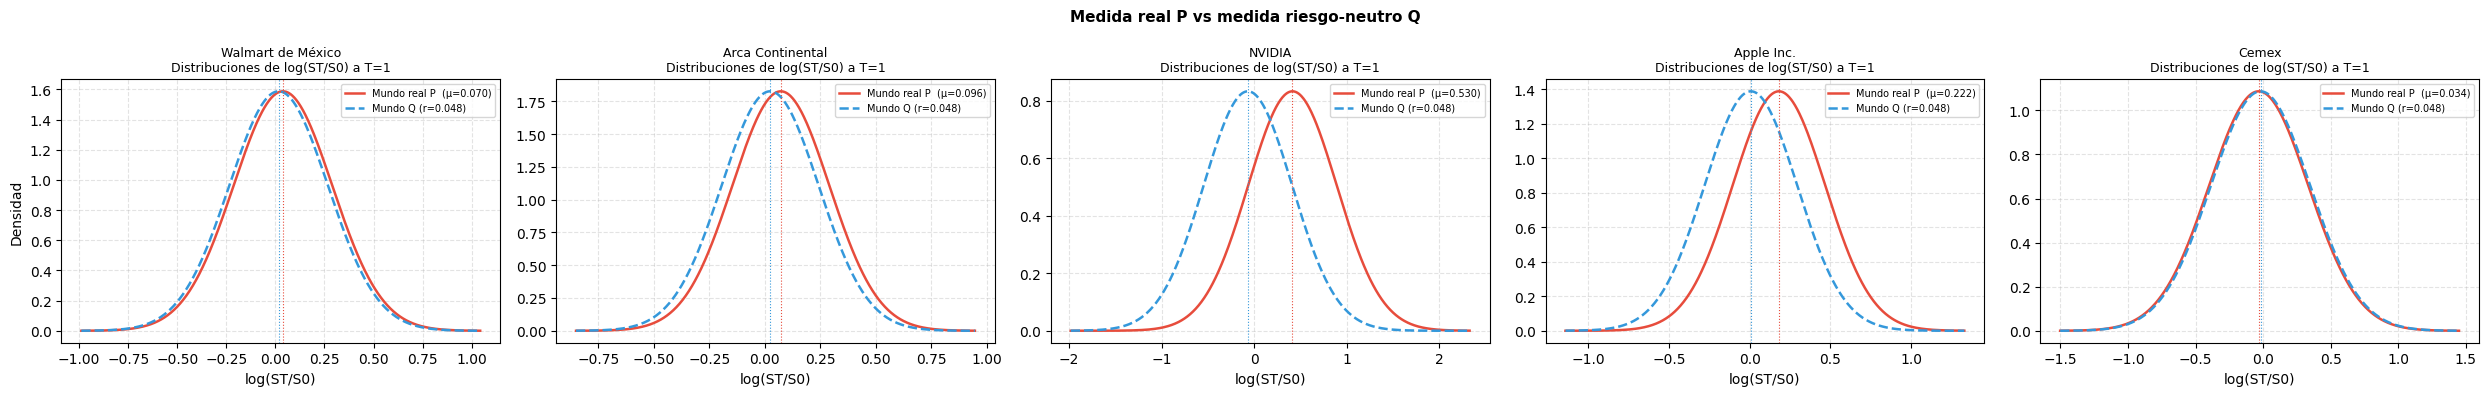

In [8]:
def graficar_mundos(tickers, params, ruta_img) -> None:
    """
    Para cada emisora: densidad Gaussiana bajo medida real P (drift μ)
    vs medida riesgo-neutro Q (drift r).
    Subplots horizontales, un par por emisora.
    """
    n = len(tickers)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]

    colores_real = '#e74c3c'
    colores_rn   = '#3498db'

    for ax, t in zip(axes, tickers):
        p    = params[t]
        S0, sigma, mu, r = p['S0'], p['sigma'], p['mu'], p['r']
        T_loc = 1.0   # horizonte para la densidad

        # Bajo medida P: log(ST/S0) ~ N((μ - σ²/2)T, σ²T)
        mu_P  = (mu  - 0.5 * sigma**2) * T_loc
        mu_Q  = (r   - 0.5 * sigma**2) * T_loc
        std_T = sigma * np.sqrt(T_loc)

        # Dominio de log-retorno a T
        x = np.linspace(mu_P - 4*std_T, mu_P + 4*std_T, 500)
        x = np.union1d(x, np.linspace(mu_Q - 4*std_T, mu_Q + 4*std_T, 500))
        x = np.sort(x)

        ax.plot(x, norm.pdf(x, mu_P, std_T), color=colores_real, lw=1.8,
                label=f'Mundo real P  (μ={mu:.3f})')
        ax.plot(x, norm.pdf(x, mu_Q, std_T), color=colores_rn,  lw=1.8,
                linestyle='--', label=f'Mundo Q (r={r:.3f})')
        ax.axvline(mu_P, color=colores_real, lw=0.8, linestyle=':')
        ax.axvline(mu_Q, color=colores_rn,   lw=0.8, linestyle=':')
        ax.set_title(f'{EMISORAS[t]}\nDistribuciones de log(ST/S0) a T=1', fontsize=9)
        ax.set_xlabel('log(ST/S0)')
        ax.set_ylabel('Densidad' if ax == axes[0] else '')
        ax.legend(fontsize=7); ax.grid(True, linestyle='--', alpha=0.35)

    plt.suptitle('Medida real P vs medida riesgo-neutro Q', fontsize=11, fontweight='bold')
    plt.tight_layout()
    fig.savefig(os.path.join(ruta_img, 'mundos_P_vs_Q.png'), dpi=150, bbox_inches='tight')
    plt.show()


graficar_mundos(TICKERS, PARAMS, RUTA_IMAGENES)


## 8. Simulación GBM bajo Medida Q

In [9]:
def simulate_gbm_rn(r: float, sigma: float, S0: float,
                     T: float, dt: float, num_paths: int,
                     seed: int = None) -> np.ndarray:
    """
    GBM bajo medida risk-neutral Q. Solución exacta (no Euler).
    dS = r·S·dt + σ·S·dW^Q
    Retorna ndarray (num_paths, num_steps).
    """
    rng       = np.random.default_rng(seed)
    num_steps = int(T / dt) + 1
    times     = np.linspace(0, T, num_steps)
    dW        = rng.standard_normal((num_paths, num_steps - 1)) * np.sqrt(dt)
    paths        = np.empty((num_paths, num_steps))
    paths[:, 0]  = S0
    paths[:, 1:] = S0 * np.exp(
        (r - 0.5 * sigma**2) * times[1:] + sigma * np.cumsum(dW, axis=1)
    )
    return paths


# Simular para todas las emisoras (ATM, ratio=1.0) para gráficas exploratorias
N_PLOT = 200   # trayectorias a graficar (100k en RAM, mostramos 200)
PATHS_MUESTRA = {}

for ticker in TICKERS:
    p = PARAMS[ticker]
    paths = simulate_gbm_rn(p['r'], p['sigma'], p['S0'],
                             T, dt, N_PLOT, seed=SEED)
    PATHS_MUESTRA[ticker] = paths

print("✅ Simulaciones de muestra listas")


✅ Simulaciones de muestra listas


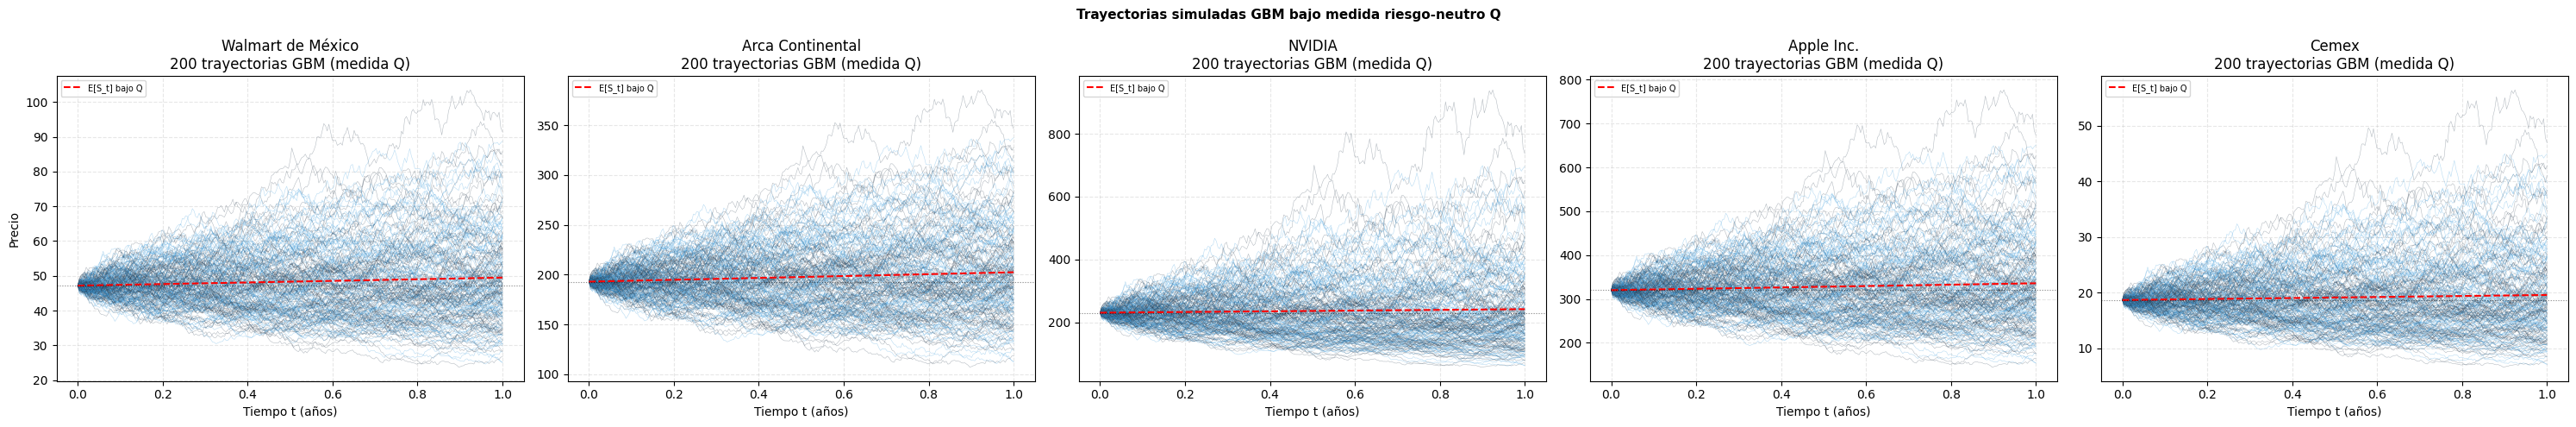

In [10]:
def graficar_trayectorias_comparativa(tickers, paths_dict, params, ruta_img) -> None:
    """
    Gráfica de trayectorias GBM simuladas para todas las emisoras,
    subplots horizontales (una por emisora).
    """
    n   = len(tickers)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1: axes = [axes]

    for ax, t in zip(axes, tickers):
        paths = paths_dict[t]
        p     = params[t]
        n_steps = paths.shape[1]
        t_axis  = np.linspace(0, T, n_steps)

        for i in range(paths.shape[0]):
            ax.plot(t_axis, paths[i], linewidth=0.4, alpha=0.35,
                    color='#3498db' if i % 2 == 0 else '#2c3e50')

        # Precio esperado bajo Q
        mu_q = p['S0'] * np.exp(p['r'] * t_axis)
        ax.plot(t_axis, mu_q, 'r--', linewidth=1.5, label='E[S_t] bajo Q')
        ax.axhline(p['S0'], color='k', linewidth=0.8, linestyle=':', alpha=0.5)

        ax.set_title(f"{EMISORAS[t]}\n{paths.shape[0]} trayectorias GBM (medida Q)")
        ax.set_xlabel("Tiempo t (años)")
        ax.set_ylabel("Precio" if ax == axes[0] else "")
        ax.legend(fontsize=7); ax.grid(True, linestyle='--', alpha=0.3)

    plt.suptitle('Trayectorias simuladas GBM bajo medida riesgo-neutro Q',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    fig.savefig(os.path.join(ruta_img, 'trayectorias_gbm.png'), dpi=150, bbox_inches='tight')
    plt.show()


graficar_trayectorias_comparativa(TICKERS, PATHS_MUESTRA, PARAMS, RUTA_IMAGENES)


## 9. LSM-Clásico (OLS Polinomial)

In [11]:
def lsm_clasico(paths: np.ndarray, K: float, r: float, T: float,
                option_type: str = 'puts',
                poly_degree: int = 3) -> tuple:
    """
    Longstaff-Schwartz con OLS polinómica.
    Retorna (precio, desv_std, stopping_times, cash_flows_finales).
    """
    ot        = option_type.lower()
    num_sim, num_steps = paths.shape
    dt_s      = T / (num_steps - 1)
    disc      = np.exp(-r * dt_s)

    def payoff(S):
        return np.maximum(K - S, 0.0) if ot == 'puts' else np.maximum(S - K, 0.0)

    cash_flows = payoff(paths).copy()

    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=poly_degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg',    LinearRegression())
    ])

    for t in range(num_steps - 2, 0, -1):
        itm = (paths[:, t] < K) if ot == 'puts' else (paths[:, t] > K)
        if itm.sum() >= poly_degree + 1:
            X = paths[itm, t].reshape(-1, 1)
            Y = cash_flows[itm, t+1] * disc
            pipe.fit(X, Y)
            cont      = np.zeros(num_sim)
            cont[itm] = pipe.predict(X)
        else:
            cont = np.zeros(num_sim)

        intrinsic    = payoff(paths[:, t])
        exercise_now = (intrinsic > 0) & (intrinsic > cont)
        cash_flows[exercise_now, t]    = intrinsic[exercise_now]
        cash_flows[exercise_now, t+1:] = 0.0

    # Stopping time y PV
    stopping = np.argmax(cash_flows > 0, axis=1)
    pv = np.array([
        cash_flows[i, stopping[i]] * np.exp(-r * dt_s * stopping[i])
        if cash_flows[i, stopping[i]] > 0 else 0.0
        for i in range(num_sim)
    ])
    return float(pv.mean()), float(pv.std(ddof=1)), stopping, pv


print("✅ lsm_clasico definida")


✅ lsm_clasico definida


## 10. LSM-SVR (Contribución Principal)

In [12]:
def lsm_svr(paths: np.ndarray, K: float, r: float, T: float,
             option_type: str = 'puts',
             C: float = SVR_C, gamma = SVR_GAMMA) -> tuple:
    """
    Longstaff-Schwartz con SVR (kernel RBF) como estimador del
    continuation value. Contribución central de la tesis.

    Correcciones clave vs versión naïve:
    - Target = payoff descontado limpio (sin fuga temporal)
    - StandardScaler antes del SVR
    - Valor final = E[PV en stopping time] (Snell envelope)
    - GBM bajo medida Q
    """
    ot        = option_type.lower()
    num_sim, num_steps = paths.shape
    dt_s      = T / (num_steps - 1)
    disc      = np.exp(-r * dt_s)

    def payoff(S):
        return np.maximum(K - S, 0.0) if ot == 'puts' else np.maximum(S - K, 0.0)

    cash_flows          = np.zeros((num_sim, num_steps))
    cash_flows[:, -1]   = payoff(paths[:, -1])

    svr_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svr',    SVR(kernel='rbf', C=C, gamma=gamma))
    ])

    for t in range(num_steps - 2, 0, -1):
        itm = (paths[:, t] < K) if ot == 'puts' else (paths[:, t] > K)
        if itm.sum() >= 3:
            X = paths[itm, t].reshape(-1, 1)
            Y = cash_flows[itm, t+1] * disc   # target limpio
            svr_pipe.fit(X, Y)
            cont      = np.zeros(num_sim)
            cont[itm] = svr_pipe.predict(X)
        else:
            cont = np.zeros(num_sim)

        intrinsic    = payoff(paths[:, t])
        exercise_now = (intrinsic > 0) & (intrinsic > cont)
        cash_flows[exercise_now, t]    = intrinsic[exercise_now]
        cash_flows[exercise_now, :t]   = 0.0
        cash_flows[exercise_now, t+1:] = 0.0

    stopping = np.argmax(cash_flows > 0, axis=1)
    pv = np.array([
        cash_flows[i, stopping[i]] * np.exp(-r * dt_s * stopping[i])
        if cash_flows[i, stopping[i]] > 0 else 0.0
        for i in range(num_sim)
    ])
    return float(pv.mean()), float(pv.std(ddof=1)), stopping, pv


print("✅ lsm_svr definida")


✅ lsm_svr definida


## 11. Black-Scholes Benchmark

In [13]:
def black_scholes_put(S0: float, K: float, T: float,
                       r: float, sigma: float) -> float:
    """Fórmula BS europea para put. Benchmark teórico."""
    if sigma <= 0 or T <= 0:
        return max(K * np.exp(-r * T) - S0, 0.0)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)


print("✅ black_scholes_put definida")


✅ black_scholes_put definida


## 12. Análisis Comparativo — 11 Ratios de Moneyness

Aquí está el análisis central de la tesis. Para cada emisora y cada ratio
S₀/K ∈ {0.75, 0.80, …, 1.25}, se comparan:
- **LS-Clásico** (OLS polinomial grado 3)
- **LS-SVR** (kernel RBF, C=SVR_C)
- **Black-Scholes** (europeo — benchmark)

> ⚠️ Con NUM_PATHS=100,000 esto tarda varios minutos por emisora.
> Baja a NUM_PATHS=1,000 para pruebas rápidas.


In [ ]:
def analizar_moneyness(ticker: str, params: dict,
                        ratios: list, num_paths: int,
                        T: float, dt: float, seed: int) -> pd.DataFrame:
    """
    Corre LS-Clásico, LS-SVR y BS para los 11 ratios de moneyness.
    Retorna DataFrame con resultados y guarda stopping times para gráficas.
    """
    p     = params[ticker]
    S0, sigma, r = p['S0'], p['sigma'], p['r']
    nombre = p['nombre']

    print(f"\n{'='*55}")
    print(f"  {nombre} ({ticker}) | S0={S0:.2f} | σ={sigma:.4f} | r={r:.4f}")
    print(f"{'='*55}")

    rows        = []
    stop_cls    = {}   # {ratio: stopping_times array}
    stop_svr    = {}
    pv_cls_all  = {}
    pv_svr_all  = {}

    for ratio in ratios:
        K = S0 / ratio
        moneyness = 'ITM' if ratio < 1 else ('ATM' if ratio == 1 else 'OTM')

        print(f"  ratio={ratio:.2f}  K={K:.2f}  [{moneyness}] ...", end=' ')

        # Simular caminos (misma semilla por ratio para comparabilidad)
        seed_r = seed + int(ratio * 100)
        paths  = simulate_gbm_rn(r, sigma, S0, T, dt, num_paths, seed=seed_r)

        # LS-Clásico
        p_cls, s_cls, st_cls, pv_cls = lsm_clasico(paths, K, r, T)
        # LS-SVR
        p_svr, s_svr, st_svr, pv_svr = lsm_svr(paths, K, r, T)
        # Black-Scholes
        p_bs = black_scholes_put(S0, K, T, r, sigma)

        stop_cls[ratio]   = st_cls
        stop_svr[ratio]   = st_svr
        pv_cls_all[ratio] = pv_cls
        pv_svr_all[ratio] = pv_svr

        diff_p   = p_cls - p_svr
        diff_s   = s_cls - s_svr
        pct_p    = diff_p / p_svr * 100 if p_svr > 0 else np.nan
        pct_s    = diff_s / s_svr * 100 if s_svr > 0 else np.nan

        rows.append({
            'Ratio':         ratio,
            'K':             round(K, 4),
            'Estado':        moneyness,
            'Cls_precio':    round(p_cls, 4),
            'Cls_desv':      round(s_cls, 4),
            'SVR_precio':    round(p_svr, 4),
            'SVR_desv':      round(s_svr, 4),
            'BS_precio':     round(p_bs,  4),
            'Diff_precio':   round(diff_p, 4),
            'Diff_desv':     round(diff_s, 4),
            'Pct_precio':    round(pct_p, 2) if not np.isnan(pct_p) else np.nan,
            'Pct_desv':      round(pct_s, 2) if not np.isnan(pct_s) else np.nan,
        })
        print(f"Cls={p_cls:.4f}(±{s_cls:.4f})  SVR={p_svr:.4f}(±{s_svr:.4f})  BS={p_bs:.4f}")

    df_res = pd.DataFrame(rows)
    return df_res, stop_cls, stop_svr, pv_cls_all, pv_svr_all


# ── Correr para todas las emisoras ───────────────────────────────────────────
RESULTADOS    = {}   # {ticker: df_resultados}
STOP_CLASICO  = {}   # {ticker: {ratio: array}}
STOP_SVR_D    = {}
PV_CLS        = {}
PV_SVR_D      = {}

for ticker in TICKERS:
    df_r, st_c, st_s, pv_c, pv_s = analizar_moneyness(
        ticker, PARAMS, RATIOS_MONEYNESS, NUM_PATHS, T, dt, SEED
    )
    RESULTADOS[ticker]   = df_r
    STOP_CLASICO[ticker] = st_c
    STOP_SVR_D[ticker]   = st_s
    PV_CLS[ticker]       = pv_c
    PV_SVR_D[ticker]     = pv_s

print("\n✅ Análisis de moneyness completo")



  Walmart de México (WALMEX.MX) | S0=47.18 | σ=0.2513 | r=0.0478
  ratio=0.75  K=62.91  [ITM] ... 

## 13. Gráficas Comparativas

In [ ]:
# Colores fijos para consistencia en toda la tesis
COLOR_CLS = '#e74c3c'   # Rojo — LS Clásico
COLOR_SVR = '#3498db'   # Azul — LS-SVR
COLOR_BS  = '#2ecc71'   # Verde — Black-Scholes


def graficar_ejercicio_vs_continuacion(paths: np.ndarray, cash_flows_finales: np.ndarray,
                                        stopping: np.ndarray, K: float,
                                        ticker: str, ratio: float,
                                        metodo: str, ruta_img: str,
                                        n_plot: int = 300) -> None:
    """
    Dos gráficas de trayectorias (igual a las originales de la tesis):
      1. Puntos rojos (ejercicio) y grises (continuación)
      2. Trayectorias coloreadas con primer ejercicio marcado en rojo
    Misma lógica que el código original, adaptada para N emisoras.
    """
    slug     = ticker.replace('.','_').replace('-','_')
    n_sim    = paths.shape[0]
    n_steps  = paths.shape[1]
    t_axis   = np.linspace(0, T, n_steps)
    total_steps = n_steps - 1

    # Recolectar puntos de ejercicio y continuación
    exercise_times, exercise_prices       = [], []
    continuation_times, continuation_prices = [], []

    for i in range(min(n_plot, n_sim)):
        st = stopping[i]
        if cash_flows_finales[i] > 0 and st > 0:
            exercise_times.append(st / total_steps)
            exercise_prices.append(paths[i, st])
        else:
            for t in range(1, n_steps):
                if paths[i, t] < K:
                    continuation_times.append(t / total_steps)
                    continuation_prices.append(paths[i, t])
                    break

    # ── Gráfica 1: Ejercicio vs Continuación (puntos) ────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    if continuation_times:
        ax.plot(continuation_times, continuation_prices, '.', color='grey',
                markersize=3, alpha=0.5, label='Continuación')
    if exercise_times:
        ax.plot(exercise_times, exercise_prices, 'rx',
                markersize=5, alpha=0.7, label='Ejercicio')
    ax.axhline(K, color='k', linewidth=0.8, linestyle='--', alpha=0.5, label=f'K={K:.2f}')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_xlabel('Tiempo t'); ax.set_ylabel(f'Precio {EMISORAS[ticker]}')
    ax.set_title(f'{EMISORAS[ticker]} — Ejercicio vs Continuación ({metodo}, ratio={ratio})')
    plt.tight_layout()
    fname = f'{slug}_{metodo}_ejercicio_puntos_ratio{str(ratio).replace(".","")}.png'
    fig.savefig(os.path.join(ruta_img, fname), dpi=150, bbox_inches='tight')
    plt.show()

    # ── Gráfica 2: Trayectorias con primer ejercicio ──────────────────────
    first_ex = np.argmax(cash_flows_finales.reshape(-1, 1) > 0, axis=1)  # proxy
    # Recalcular primer paso con payoff > 0
    cf_matrix = np.zeros((min(n_plot, n_sim), n_steps))
    for i in range(min(n_plot, n_sim)):
        st = stopping[i]
        if st > 0:
            cf_matrix[i, st] = 1

    fig, ax = plt.subplots(figsize=(10, 5))
    for i in range(min(n_plot, n_sim)):
        idx = stopping[i] if stopping[i] > 0 else n_steps - 1
        ax.plot(t_axis[:idx+1], paths[i, :idx+1],
                color='lightgray', linewidth=0.4, linestyle='-')
        ax.plot(t_axis[idx:],   paths[i, idx:],
                color='darkgray', linewidth=0.4, linestyle='--')
        if stopping[i] > 0:
            ax.plot(t_axis[idx], paths[i, idx], 'rx', markersize=4, alpha=0.6)

    ax.axhline(K, color='k', linewidth=0.9, linestyle='--', alpha=0.5, label=f'K={K:.2f}')
    ax.set_xlabel('Tiempo t'); ax.set_ylabel(f'Precio {EMISORAS[ticker]}')
    ax.set_title(f'{EMISORAS[ticker]} — Trayectorias con primer ejercicio ({metodo}, ratio={ratio})')
    ax.grid(True, linestyle='--', alpha=0.35)
    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0],[0], color='lightgray', lw=1, label='Antes del ejercicio'),
        Line2D([0],[0], color='darkgray',  lw=1, linestyle='--', label='Después del ejercicio'),
        Line2D([0],[0], marker='x', color='red', lw=0, markersize=6, label='Primer ejercicio'),
    ]
    ax.legend(handles=legend_elems, fontsize=7)
    plt.tight_layout()
    fname2 = f'{slug}_{metodo}_trayectorias_ejercicio_ratio{str(ratio).replace(".","")}.png'
    fig.savefig(os.path.join(ruta_img, fname2), dpi=150, bbox_inches='tight')
    plt.show()


# Generar gráficas de ejercicio para ratio ATM (1.0) de cada emisora
for ticker in TICKERS:
    ratio_atm = 1.0
    p    = PARAMS[ticker]
    K    = p['S0'] / ratio_atm
    seed_r = SEED + int(ratio_atm * 100)
    paths  = simulate_gbm_rn(p['r'], p['sigma'], p['S0'], T, dt, min(NUM_PATHS, 500), seed=seed_r)
    _, _, st_cls, pv_cls = lsm_clasico(paths, K, p['r'], T)
    _, _, st_svr, pv_svr = lsm_svr(paths, K, p['r'], T)

    print(f"── {EMISORAS[ticker]} | ratio=1.0 | LS-Clásico ──")
    graficar_ejercicio_vs_continuacion(paths, pv_cls, st_cls, K, ticker, ratio_atm, 'LSClasico', RUTA_IMAGENES)
    print(f"── {EMISORAS[ticker]} | ratio=1.0 | LS-SVR ──")
    graficar_ejercicio_vs_continuacion(paths, pv_svr, st_svr, K, ticker, ratio_atm, 'LSSVR', RUTA_IMAGENES)


In [ ]:
def graficar_distribucion_tiempos(ticker: str, stop_cls: dict, stop_svr: dict,
                                   ratios: list, ruta_img: str) -> None:
    """
    Dos gráficas de tiempos de ejercicio (columnas rojo=clásico, azul=SVR):
      1. Densidad (KDE) de los tiempos de ejercicio por ratio
      2. Boxplots de tiempos por ratio
    """
    slug  = ticker.replace('.','_').replace('-','_')
    n_rat = len(ratios)
    num_steps = int(T / dt) + 1

    # ── 1. KDE de tiempos de ejercicio ───────────────────────────────────
    fig, axes = plt.subplots(1, n_rat, figsize=(2.5*n_rat, 4), sharey=False)
    if n_rat == 1: axes = [axes]
    for ax, ratio in zip(axes, ratios):
        sc = stop_cls[ratio]; ss = stop_svr[ratio]
        sc_nz = sc[sc > 0] / (num_steps - 1)
        ss_nz = ss[ss > 0] / (num_steps - 1)
        if len(sc_nz) > 10:
            from scipy.stats import gaussian_kde
            x_kde = np.linspace(0, 1, 200)
            ax.fill_between(x_kde, gaussian_kde(sc_nz)(x_kde),
                            alpha=0.55, color=COLOR_CLS, label='LS-Clásico')
        if len(ss_nz) > 10:
            from scipy.stats import gaussian_kde
            x_kde = np.linspace(0, 1, 200)
            ax.fill_between(x_kde, gaussian_kde(ss_nz)(x_kde),
                            alpha=0.55, color=COLOR_SVR, label='LS-SVR')
        ax.set_title(f'ratio={ratio}', fontsize=8)
        ax.set_xlabel('t/T'); ax.set_ylabel('Densidad' if ax == axes[0] else '')
        ax.grid(True, linestyle='--', alpha=0.3)
        if ax == axes[0]: ax.legend(fontsize=6)
    plt.suptitle(f'{EMISORAS[ticker]} — Distribución de tiempos de ejercicio',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    fname = f'{slug}_distribucion_tiempos_densidad.png'
    fig.savefig(os.path.join(ruta_img, fname), dpi=150, bbox_inches='tight')
    plt.show()

    # ── 2. Boxplots de tiempos ────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    positions_cls = np.arange(n_rat) * 3
    positions_svr = positions_cls + 1

    data_cls = [stop_cls[r][stop_cls[r] > 0] / (num_steps-1) for r in ratios]
    data_svr = [stop_svr[r][stop_svr[r] > 0] / (num_steps-1) for r in ratios]

    bp1 = ax.boxplot(data_cls, positions=positions_cls, patch_artist=True,
                     widths=0.7, medianprops=dict(color='white', lw=2))
    bp2 = ax.boxplot(data_svr, positions=positions_svr, patch_artist=True,
                     widths=0.7, medianprops=dict(color='white', lw=2))

    for patch in bp1['boxes']: patch.set(facecolor=COLOR_CLS, alpha=0.8)
    for patch in bp2['boxes']: patch.set(facecolor=COLOR_SVR, alpha=0.8)

    ax.set_xticks(positions_cls + 0.5)
    ax.set_xticklabels([str(r) for r in ratios], fontsize=8)
    ax.set_xlabel('Ratio S₀/K'); ax.set_ylabel('Tiempo de ejercicio (t/T)')
    ax.set_title(f'{EMISORAS[ticker]} — Cuartiles de tiempos de ejercicio')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor=COLOR_CLS, label='LS-Clásico'),
                        Patch(facecolor=COLOR_SVR, label='LS-SVR')], fontsize=8)
    plt.tight_layout()
    fname2 = f'{slug}_distribucion_tiempos.png'
    fig.savefig(os.path.join(ruta_img, fname2), dpi=150, bbox_inches='tight')
    plt.show()


for ticker in TICKERS:
    graficar_distribucion_tiempos(ticker, STOP_CLASICO[ticker], STOP_SVR_D[ticker],
                                   RATIOS_MONEYNESS, RUTA_IMAGENES)


In [ ]:
def graficar_primas(ticker: str, df_res: pd.DataFrame, ruta_img: str) -> None:
    """
    Gráfica de primas vs ratio de moneyness:
    LS-Clásico (rojo), LS-SVR (azul), Black-Scholes (verde).
    """
    slug = ticker.replace('.','_').replace('-','_')
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(df_res['Ratio'], df_res['Cls_precio'], 'o-',
            color=COLOR_CLS, lw=1.8, ms=5, label='LS-Clásico')
    ax.plot(df_res['Ratio'], df_res['SVR_precio'], 's--',
            color=COLOR_SVR, lw=1.8, ms=5, label='LS-SVR')
    ax.plot(df_res['Ratio'], df_res['BS_precio'],  '^:',
            color=COLOR_BS,  lw=1.5, ms=4, label='Black-Scholes (europeo)')

    ax.axvline(1.0, color='k', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.text(1.01, ax.get_ylim()[1]*0.95, 'ATM', fontsize=7, color='k')
    ax.set_xlabel('Ratio S₀/K'); ax.set_ylabel('Prima (USD/MXN)')
    ax.set_title(f'{EMISORAS[ticker]} — Primas de Longstaff-Schwartz')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.35)
    plt.tight_layout()
    fig.savefig(os.path.join(ruta_img, f'{slug}_Primas.png'), dpi=150, bbox_inches='tight')
    plt.show()


def graficar_variabilidad(ticker: str, df_res: pd.DataFrame, ruta_img: str) -> None:
    """
    Gráfica de desviación estándar del precio vs ratio.
    Columnas: LS-Clásico (rojo) vs LS-SVR (azul).
    """
    slug = ticker.replace('.','_').replace('-','_')
    fig, ax = plt.subplots(figsize=(9, 5))
    x   = np.arange(len(df_res))
    w   = 0.35
    b1  = ax.bar(x - w/2, df_res['Cls_desv'], w, color=COLOR_CLS, alpha=0.85, label='LS-Clásico')
    b2  = ax.bar(x + w/2, df_res['SVR_desv'], w, color=COLOR_SVR, alpha=0.85, label='LS-SVR')
    ax.set_xticks(x)
    ax.set_xticklabels([str(r) for r in df_res['Ratio']], fontsize=8)
    ax.set_xlabel('Ratio S₀/K'); ax.set_ylabel('Desviación estándar del precio')
    ax.set_title(f'{EMISORAS[ticker]} — Variabilidad de primas')
    ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.35)
    plt.tight_layout()
    fig.savefig(os.path.join(ruta_img, f'{slug}_Primas_Variabilidad.png'), dpi=150, bbox_inches='tight')
    plt.show()


for ticker in TICKERS:
    graficar_primas(ticker, RESULTADOS[ticker], RUTA_IMAGENES)
    graficar_variabilidad(ticker, RESULTADOS[ticker], RUTA_IMAGENES)


## 14. Análisis de Sensibilidad a C (SVR)

In [ ]:
def sensibilidad_C(ticker: str, params: dict, ratio_atm: float = 1.0,
                    Cs: list = None, T: float = 1.0, dt: float = 1/252,
                    num_paths: int = 5000, seed: int = SEED) -> pd.DataFrame:
    """
    Precio LSM-SVR ATM en función de C.
    Justifica la elección de C=SVR_C en la tesis.
    """
    if Cs is None:
        Cs = [0.01, 0.1, 1, 5, 10, 50, 100, 500]

    p  = params[ticker]
    K  = p['S0'] / ratio_atm
    paths = simulate_gbm_rn(p['r'], p['sigma'], p['S0'], T, dt, num_paths, seed=seed)

    rows = []
    for C in Cs:
        precio, desv, _, _ = lsm_svr(paths, K, p['r'], T, C=C)
        rows.append({'C': C, 'Precio': round(precio, 5), 'Desv': round(desv, 5)})
        print(f"  C={C:<6}  precio={precio:.5f}  desv={desv:.5f}")

    return pd.DataFrame(rows)


fig_rows = (len(TICKERS) + 1) // 2
fig_cols = min(2, len(TICKERS))
fig, axes = plt.subplots(fig_rows, fig_cols,
                          figsize=(7*fig_cols, 4*fig_rows), squeeze=False)
axes_flat = axes.flatten()

for idx, ticker in enumerate(TICKERS):
    print(f"\n── Sensibilidad C — {EMISORAS[ticker]} ──")
    df_C = sensibilidad_C(ticker, PARAMS)

    ax = axes_flat[idx]
    ax.semilogx(df_C['C'], df_C['Precio'], 'o-', color=COLOR_SVR, lw=1.8, ms=5)
    ax.fill_between(df_C['C'],
                     df_C['Precio'] - df_C['Desv'],
                     df_C['Precio'] + df_C['Desv'],
                     alpha=0.2, color=COLOR_SVR)
    ax.axvline(SVR_C, color='red', linestyle='--', lw=1, label=f'C elegido={SVR_C}')
    ax.set_xlabel('C (escala log)'); ax.set_ylabel('Precio ATM')
    ax.set_title(f'{EMISORAS[ticker]} — Sensibilidad a C')
    ax.legend(fontsize=7); ax.grid(True, linestyle='--', alpha=0.35)

# Ocultar subplots vacíos
for ax in axes_flat[len(TICKERS):]:
    ax.set_visible(False)

plt.suptitle('Análisis de sensibilidad al hiperparámetro C del SVR',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RUTA_IMAGENES, 'sensibilidad_C_svr.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Análisis de sensibilidad a C completo")


## 15. Exportar Tablas LaTeX y Resumen

In [ ]:
def tabla_latex_comparativa(ticker: str, df_res: pd.DataFrame) -> str:
    """
    Genera el código LaTeX de la tabla comparativa LS-Clásico vs LS-SVR
    (igual al ejemplo del documento de tesis).
    """
    slug  = ticker.replace('.','_').replace('-','_')
    nombre = EMISORAS[ticker]
    lines = []
    lines.append(r'\begin{table}[h!]')
    lines.append(r'\centering')
    lines.append(r'\resizebox{\textwidth}{!}{%')
    lines.append(r'\begin{tabular}{|c|cc|cc|cc|cc|c|}')
    lines.append(r'\hline')
    lines.append(r' & \multicolumn{2}{c|}{\textbf{LS Clásico}} & '
                 r'\multicolumn{2}{c|}{\textbf{LS-SVR}} & '
                 r'\multicolumn{2}{c|}{\textbf{Diferencia}} & '
                 r'\multicolumn{2}{c|}{\textbf{\% Variación}} & '
                 r'\textbf{Estado} \\ \hline')
    lines.append(r'\textbf{Ratio} & \textbf{Precio} & \textbf{Desv.} & '
                 r'\textbf{Precio} & \textbf{Desv.} & '
                 r'\textbf{Precio} & \textbf{Desv.} & '
                 r'\textbf{Precio} & \textbf{Desv.} & '
                 r'\textbf{Mercado} \\ \hline')

    for _, row in df_res.iterrows():
        pp = f"{row['Pct_precio']:.2f}\\%" if pd.notna(row['Pct_precio']) else 'N/A'
        ps = f"{row['Pct_desv']:.2f}\\%"   if pd.notna(row['Pct_desv'])   else 'N/A'
        lines.append(
            f"{row['Ratio']:.2f} & {row['Cls_precio']:.4f} & {row['Cls_desv']:.4f} & "
            f"{row['SVR_precio']:.4f} & {row['SVR_desv']:.4f} & "
            f"{row['Diff_precio']:.4f} & {row['Diff_desv']:.4f} & "
            f"{pp} & {ps} & {row['Estado']} \\\\"
        )
    lines.append(r'\hline')
    lines.append(r'\end{tabular}%')
    lines.append(r'}')
    lines.append(f'\\caption{{{nombre}. Comparativa de Modelos: Clásico vs. SVR}}')
    lines.append(f'\\label{{tab:comparativa_{slug}}}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)


def tabla_latex_bs(ticker: str, df_res: pd.DataFrame) -> str:
    """Tabla LaTeX con primas Black-Scholes para los 11 ratios."""
    slug   = ticker.replace('.','_').replace('-','_')
    nombre = EMISORAS[ticker]
    lines  = []
    lines.append(r'\begin{table}[h!]')
    lines.append(r'\centering')
    lines.append(r'\begin{tabular}{|c|c|c|}')
    lines.append(r'\hline')
    lines.append(r'\textbf{Ratio S$_0$/K} & \textbf{Prima BS (USD/MXN)} & \textbf{Estado} \\ \hline')
    for _, row in df_res.iterrows():
        lines.append(f"{row['Ratio']:.2f} & {row['BS_precio']:.4f} & {row['Estado']} \\\\")
    lines.append(r'\hline')
    lines.append(r'\end{tabular}')
    lines.append(f'\\caption{{{nombre}. Primas Black-Scholes europeas (benchmark)}}')
    lines.append(f'\\label{{tab:bs_{slug}}}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)


# Exportar todo
for ticker in TICKERS:
    slug = ticker.replace('.','_').replace('-','_')
    df_r = RESULTADOS[ticker]

    # CSV
    ruta_csv = os.path.join(RUTA_DATOS, f'{slug}_resultados_moneyness.csv')
    df_r.to_csv(ruta_csv, index=False)
    print(f"✅ CSV: {ruta_csv}")

    # LaTeX comparativa
    latex_comp = tabla_latex_comparativa(ticker, df_r)
    ruta_tex = os.path.join(RUTA_DATOS, f'{slug}_tabla_comparativa.tex')
    with open(ruta_tex, 'w') as f:
        f.write(latex_comp)
    print(f"✅ LaTeX comparativa: {ruta_tex}")

    # LaTeX BS
    latex_bs = tabla_latex_bs(ticker, df_r)
    ruta_tex_bs = os.path.join(RUTA_DATOS, f'{slug}_tabla_bs.tex')
    with open(ruta_tex_bs, 'w') as f:
        f.write(latex_bs)
    print(f"✅ LaTeX BS: {ruta_tex_bs}")

    # Imprimir tabla en pantalla
    print(f"\n=== {EMISORAS[ticker]} — Resultados ===")
    print(df_r[['Ratio','Estado','Cls_precio','Cls_desv',
                 'SVR_precio','SVR_desv','BS_precio',
                 'Diff_precio','Pct_precio']].to_string(index=False))


## 16. Estadísticos descriptivos — Tabla LaTeX

Tabla de dos columnas para la sección de distribución de rendimientos.


In [ ]:
def tabla_latex_descriptivos(tickers, desc_dict, nombres) -> str:
    """Tabla LaTeX con estadísticos descriptivos, una columna por emisora."""
    rows_names = list(next(iter(desc_dict.values())).keys())
    cols       = ' & '.join([f'\\textbf{{{nombres[t]}}}' for t in tickers])
    lines      = [
        r'\begin{table}[h!]',
        r'\centering',
        r'\begin{tabular}{l' + 'r'*len(tickers) + '}',
        r'  \hline',
        f'  \textbf{{Estadístico}} & {cols} \\\\',
        r'  \hline',
    ]
    for row in rows_names:
        vals = ' & '.join([f"{desc_dict[t][row]:.6f}" for t in tickers])
        lines.append(f'  {row} & {vals} \\\\')
    lines += [
        r'  \hline',
        r'\end{tabular}',
        r'\caption{Estadísticos descriptivos de rendimientos log-diarios. Elaboración propia}',
        r'\label{tab:Descriptivos_emisoras}',
        r'\end{table}',
    ]
    return '\n'.join(lines)


latex_desc = tabla_latex_descriptivos(TICKERS, desc, NOM)
ruta_desc  = os.path.join(RUTA_DATOS, 'tabla_descriptivos.tex')
with open(ruta_desc, 'w') as f:
    f.write(latex_desc)

print("=== Tabla LaTeX descriptivos ===")
print(latex_desc)
print(f"\n✅ Guardada en: {ruta_desc}")
